# Car example

from lecture!

In [27]:
# Necessary for simulation to be run as HTML
%matplotlib inline
from IPython.display import HTML
from IPython.display import display


# Packages etc
import numpy as np                              # General math
import matplotlib.pyplot as plt                 # For plotting
from matplotlib.animation import FuncAnimation  # For animation
from scipy.linalg import solve_continuous_are   # For solving ricatti equation

In [28]:
# Tableau 10 color scheme (hex)
tabBlue   = "#4E79A7"
tabGreen  = "#59A14F"
tabBrown  = "#9C755F"
tabOrange = "#F28E2B"
tabYellow = "#EDC948"
tabGray   = "#BAB0AC"
tabRed    = "#E15759"
tabPurple = "#B07AA1"
tabTeal   = "#76B7B2"
tabPink   = "#FF9DA7"

## Physics

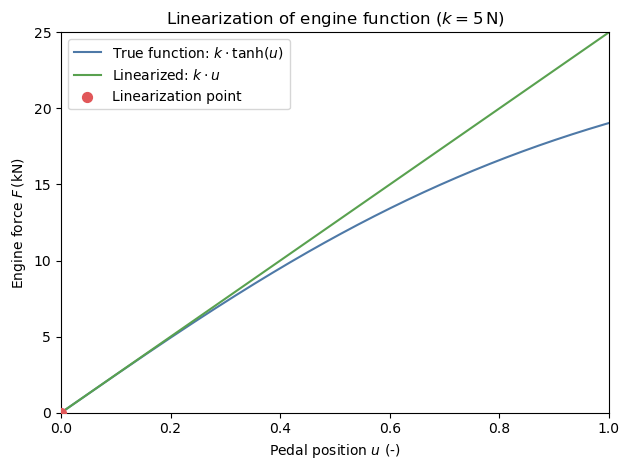

In [58]:
# Engine function
k = 25e3       # Engine acceleration coefficient (N)

# Plot function and linearization 
u = np.linspace(0, 1, 400)

plt.plot(u, k * np.tanh(u) * 1e-3, tabBlue, label=r"True function: $k \cdot \tanh(u)$")
plt.plot(u, k * u * 1e-3, tabGreen, label=r"Linearized: $k \cdot u$")
plt.scatter(0, 0, marker='o', s=50, color=tabRed, zorder=10, label="Linearization point")
plt.xlabel(r"Pedal position $u$ (-)")
plt.ylabel(r"Engine force $F\,(\mathrm{kN})$")
plt.title(r"Linearization of engine function ($k=5\,\mathrm{N}$)")
plt.xlim(0,1)
plt.ylim(0,k*1e-3)
plt.legend()
plt.tight_layout()
plt.savefig("engine_function.pdf")
plt.show()
plt.close()

In [30]:
# Pendulum parameters
m = 500    # car mass  (kg)
c = 5    # Friction factor air
F_dist = 5e3    # Distortion, may be from engine itself

# "Make a step", so getting the new state from the old state after one dt timestep considering the actions
def step(state, action, dt):
    # Read state and action
    x, x_dot = state              # position, velocity (current state)
    u = action                      # Throttle pedal position (in %)

    # Definition of the differential equation
    x_ddot = (k * np.tanh(u) - c * x_dot - F_dist) / m    # Acceleration nonlinear ODE

    # Explicit Euler update
    x_new         = x         + dt * x_dot
    x_dot_new     = x_dot     + dt * x_ddot

    return np.array([x_new, x_dot_new])

## Simulation

In [31]:
# Simulation parameters
dt = 1e-3           # Step size (smaller is numerically more stable, but needs more time to calculate)
time_total = 5      # Total time
steps = int(time_total / dt)    # Number of simulation steps

# For plotting we need to save the states over time
time = np.linspace(0, time_total, steps)

# Simulation for whole time span
def simulation(initial_state, actor_function):

    states_log = np.zeros((steps, 2))
    action_log = np.zeros(steps)

    # Set initial state
    states_log[0, :] = initial_state

    # Loop over all time steps
    for i in range(steps-1):
        state = states_log[i, :]
        t = i * dt

        # actor_function is a function that defines the action (acceleration). It can be "None" (a = 0), "PID" (for PID controller) or ....
        # it must have knowledge about the state and the current time
        a = actor_function(state, t)  # Define actor function externally, can be just 0 or PID or whatever...
        action_log[i] = a
        
        # Get next state
        states_log[i+1,:] = step(states_log[i,:], a, dt)
    
    # Just to get last value (same length as states_log)
    action_log[-1] = action_log[-2]
    return states_log, action_log

## Plots

In [32]:
# Plot of the state over time
def show_plots(x_dot, u, x_dot_set = None, title = None):
    plt.close('all')
    fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    
    labels = [r'$\dot{x}\,[\mathrm{m/s}]$', r'$u\,[-]$']
    colors = [tabBlue, tabGreen, tabRed]

    if x_dot_set is not None:
        axs[0].axhline(y = x_dot_set, color=tabOrange,linestyle='--', label=r"$\dot{x}_{set}$")

    axs[0].plot(time, x_dot[:, 1], colors[0], label=r"$\dot{x}$")
    axs[0].set_ylabel(labels[0])
    axs[0].set_ylim(0, max(np.max(x_dot[:, 1]), x_dot_set) * 1.01)
    axs[0].legend(loc="lower right")
    axs[0].grid()

    axs[1].plot(time, u[:], colors[2])
    axs[1].set_ylabel(labels[1])
    axs[1].set_ylim(0, 1.01)
    axs[1].grid()
        
    axs[-1].set_xlim(0, time[-1])
    axs[-1].set_xlabel(r'Time $t$ [s]')
    if title is None:
        fig.suptitle("States and actions over time", fontsize=14)    
    else:
        fig.suptitle(title, fontsize=14)    
    plt.tight_layout()
    plt.tight_layout()
    plt.show()

## PID

In [33]:
def make_af_pid(x_dot_set, Kp, Ki, Kd, u_max=1.0):
    integral = 0.0
    last_error = 0.0

    def pid_actor(state, t):
        nonlocal integral, last_error

        # Get state (
        # keep in mind: we just measure theta in reality, since this is the sensor output y(t) --> We have to work only with theta
        x_dot = state[1]
        error = x_dot_set - x_dot

        integral += error * dt
        integral = np.clip(integral, -5.0, 5.0)  # anti-windup: Prevents extreme integral values for long integration times

        derivative = (error - last_error) / dt
        last_error = error

        a = Kp * error + Ki * integral + Kd * derivative     # Actor needs to work against the error!
        return np.clip(a, -u_max, u_max)

    return pid_actor

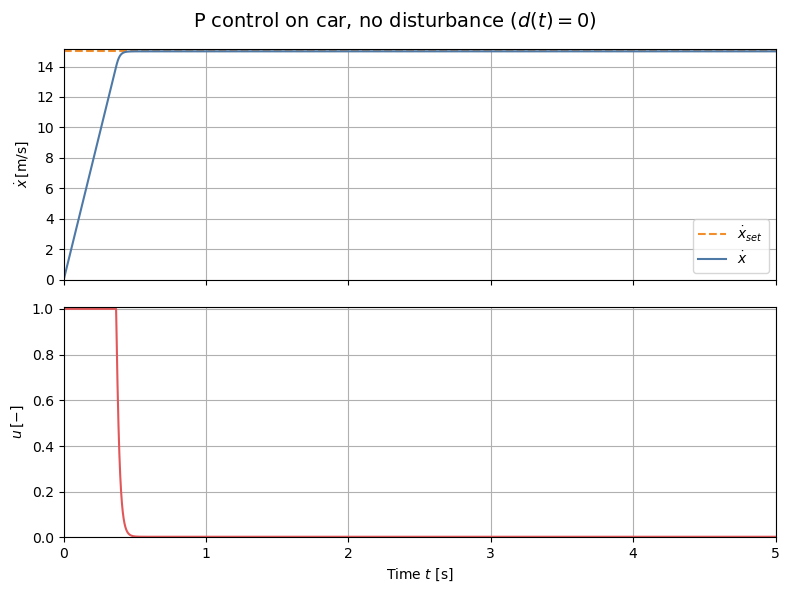

In [34]:
# Get initial state (standing vehicle)
init_state = np.array([
    0.0,                           # x
    0.0,                           # x_dot
])

# Set the desired velocity!
x_dot_set = 15   # Set wanted velocity (m/s)

# TODO: Tune PID by applying Kp, Ki and Kd
af_pid = make_af_pid(x_dot_set=x_dot_set, Kp=1, Ki=0, Kd=0)

# Let the simulation run!
F_dist = 0  # Disturbance
x_dot_1, u_1 = simulation(init_state, actor_function=af_pid)
show_plots(x_dot_1, u_1, x_dot_set=x_dot_set, title="P control on car, no disturbance ($d(t) = 0$)")

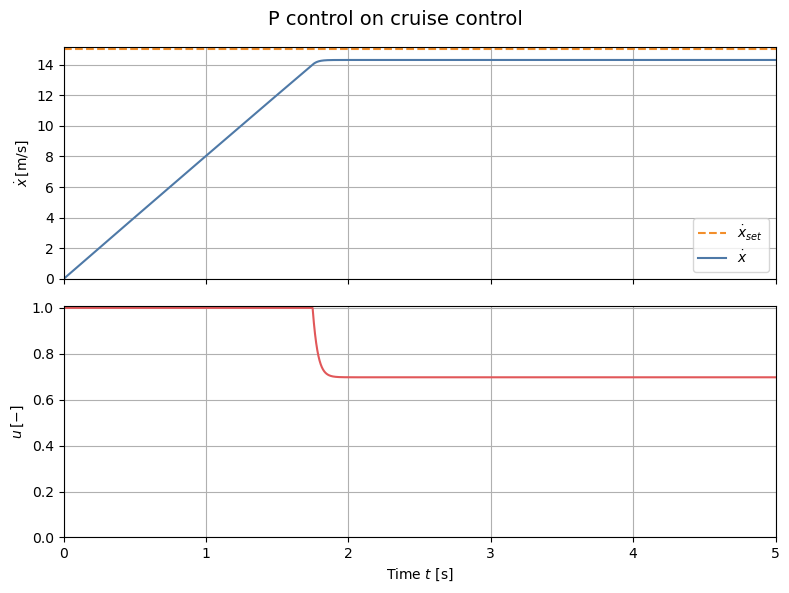

In [35]:
# Let the simulation run!
F_dist = 15e3  # Disturbance
af_pid = make_af_pid(x_dot_set=x_dot_set, Kp=1, Ki=0, Kd=0)
x_dot_2, u_2 = simulation(init_state, actor_function=af_pid)
show_plots(x_dot_2, u_2, x_dot_set=x_dot_set, title="P control on cruise control")

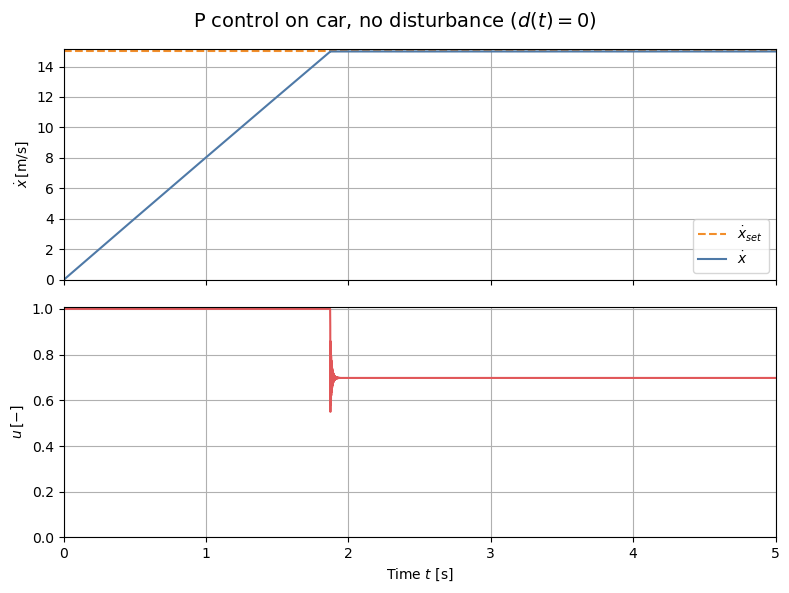

In [36]:
af_pid = make_af_pid(x_dot_set=x_dot_set, Kp=60, Ki=0, Kd=0)
x_dot_3, u_3 = simulation(init_state, actor_function=af_pid)
show_plots(x_dot_3, u_3, x_dot_set=x_dot_set, title="P control on car, no disturbance ($d(t) = 0$)")

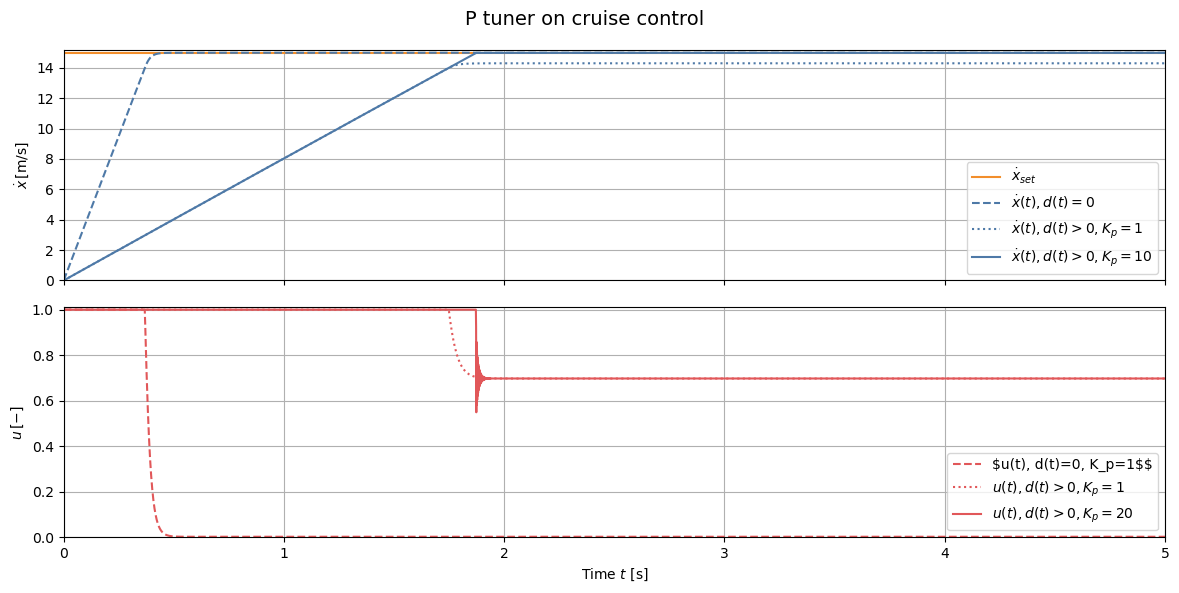

In [37]:
# Show both plots (for presentation)
plt.close()
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
labels = [r'$\dot{x}\,[\mathrm{m/s}]$', r'$u\,[-]$']
colors = [tabBlue, tabGreen, tabRed]
axs[0].axhline(y = x_dot_set, color=tabOrange, label=r"$\dot{x}_{set}$")
axs[0].plot(time, x_dot_1[:, 1], color=colors[0], linestyle='--', label=r"$\dot{x}(t), d(t)=0$")
axs[0].plot(time, x_dot_2[:, 1], color=colors[0], linestyle=':', label=r"$\dot{x}(t), d(t)>0, K_p=1$")
axs[0].plot(time, x_dot_3[:, 1], color=colors[0], label=r"$\dot{x}(t), d(t)>0, K_p=10$")
axs[0].set_ylabel(labels[0])
axs[0].set_ylim(0, max(np.max(x_dot_1[:, 1]), x_dot_set) * 1.01)
axs[0].legend(loc="lower right")
axs[0].grid()

axs[1].plot(time, u_1, color=colors[2], linestyle='--', label=r"$u(t), d(t)=0, K_p=1$$")
axs[1].plot(time, u_2, color=colors[2], linestyle=':', label=r"$u(t), d(t)>0, K_p=1$")
axs[1].plot(time, u_3, color=colors[2], label=r"$u(t), d(t)>0, K_p=20$")
axs[1].legend(loc="lower right")
axs[1].set_ylabel(labels[1])
axs[1].set_ylim(0, 1.01)
axs[1].grid()
    
axs[-1].set_xlim(0, time[-1])
axs[-1].set_xlabel(r'Time $t$ [s]')
title = "P tuner on cruise control"
fig.suptitle(title, fontsize=14) 
#fig.text(0.5, 0.93,r"$K_p = 1,\; K_i = 0,\; K_d = 0$",ha='center',fontsize=10)   
plt.tight_layout()
plt.savefig(title + ".pdf")
plt.show()

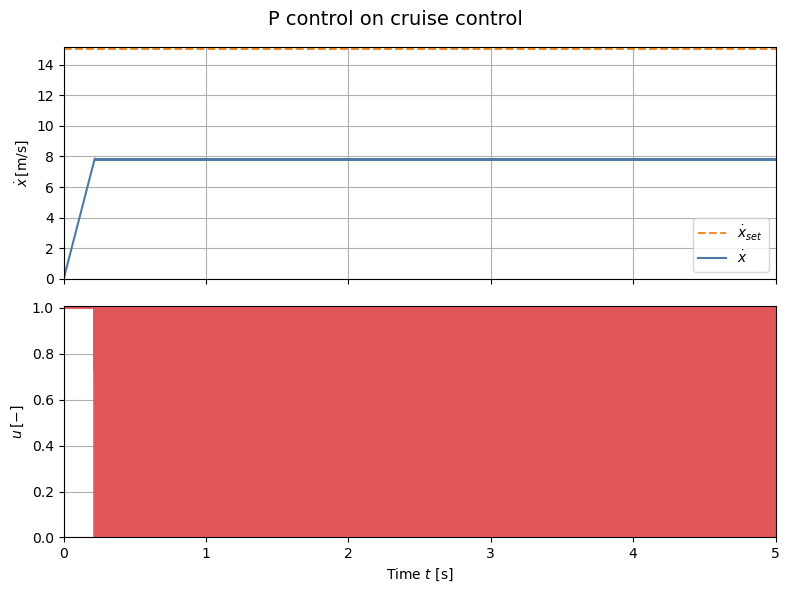

In [38]:
# Let the simulation run!
F_dist = 1e3  # Disturbance
af_pid = make_af_pid(x_dot_set=x_dot_set, Kp=50, Ki=0, Kd=10)
x_dot_4, u_4 = simulation(init_state, actor_function=af_pid)
show_plots(x_dot_4, u_4, x_dot_set=x_dot_set, title="P control on cruise control")